In [10]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
import pandas as pd
from scipy.optimize import brentq
from IPython.display import display, Math, Latex

# 设置绘图风格 (可选，如果报错可改为 'ggplot')
plt.style.use('seaborn-v0_8-whitegrid')

# ==========================================
# 🟢 1. 考试配置区 (在这里修改数值)
# ==========================================
PARAMS = {
    'L': 2.0,           # 梁长 (m)
    'b': 0.02,          # 宽度 (m)
    'h': 0.005,         # 高度 (m)
    'E': 210e9,         # 弹性模量 (Pa)
    'rho': 7850         # 密度 (kg/m^3)
}

# 自动计算导出参数
PARAMS['I'] = PARAMS['b'] * PARAMS['h']**3 / 12       # 截面惯性矩 I (m^4)
PARAMS['m_bar'] = PARAMS['rho'] * PARAMS['b'] * PARAMS['h'] # 线密度 (kg/m) !!! 注意是线密度不是总质量
PARAMS['EI'] = PARAMS['E'] * PARAMS['I']

print("✅ 参数已加载")
print(f"   线密度 m_bar: {PARAMS['m_bar']:.4f} kg/m")
print(f"   抗弯刚度 EI : {PARAMS['EI']:.2f} N*m^2")

✅ 参数已加载
   线密度 m_bar: 0.7850 kg/m
   抗弯刚度 EI : 43.75 N*m^2


In [11]:
def show_symbolic_derivation():
    # 定义符号
    x, L, beta = sp.symbols('x L beta')
    A, B, C, D = sp.symbols('A B C D')
    
    # 1. 欧拉-伯努利梁通解
    Y_x = A*sp.sin(beta*x) + B*sp.cos(beta*x) + C*sp.sinh(beta*x) + D*sp.cosh(beta*x)
    
    display(Math(r"\textbf{1. 梁横向振动通解 (General Solution):}"))
    display(Math(r"Y(x) = " + sp.latex(Y_x)))
    
    # 2. 悬臂梁边界条件 (Clamped-Free)
    # x=0: Y=0, Y'=0
    # 代入后可得 B+D=0 (D=-B) 和 A+C=0 (C=-A)
    # 简化后的振型函数（令 A=1 作为比例因子）
    sigma = (sp.sinh(beta*L) + sp.sin(beta*L)) / (sp.cosh(beta*L) + sp.cos(beta*L)) # 这里的 sigma 符号定义不同教材可能互为倒数，此处按标准形式
    
    # 注意：通常写为 Y(x) = C [ (cosh bx - cos bx) - sigma (sinh bx - sin bx) ]
    # 我们直接展示最终形式
    
    display(Math(r"\textbf{2. 施加边界条件 (x=0固定, x=L自由):}"))
    display(Math(r"Y(0) = 0, \quad Y'(0) = 0 \implies D = -B, \quad C = -A"))
    display(Math(r"\textbf{3. 特征方程 (Frequency Equation):}"))
    
    # 特征方程
    char_eq = sp.cos(beta*L) * sp.cosh(beta*L) + 1
    display(Math(sp.latex(char_eq) + " = 0"))

# 运行展示
show_symbolic_derivation()

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [15]:
def solve_numerically(params):
    # 特征方程函数: cos(z)cosh(z) + 1 = 0
    def char_eq(z):
        return np.cos(z) * np.cosh(z) + 1

    # 搜索区间 (悬臂梁前三阶根的经验范围)
    search_ranges = [(1.5, 2.5), (4.0, 5.0), (7.0, 8.5)]
    results = []

    for i, (low, high) in enumerate(search_ranges):
        # 1. 求解 beta*L
        betaL = brentq(char_eq, low, high)
        
        # 2. 计算物理量
        L_val = params['L']
        beta = betaL / L_val
        
        # omega = (beta^2) * sqrt(EI / m_bar)
        omega = (beta**2) * np.sqrt(params['EI'] / params['m_bar'])
        freq_hz = omega / (2 * np.pi)
        
        # 3. 计算振型系数 sigma (用于绘图)
        # formula: sigma = (cosh(bL) + cos(bL)) / (sinh(bL) + sin(bL))
        sigma = (np.cosh(betaL) + np.cos(betaL)) / (np.sinh(betaL) + np.sin(betaL))

        results.append({
            "Mode": int(i+1),
            "beta*L": betaL,
            "beta (1/m)": beta,
            "Omega (rad/s)": omega,
            "Freq (Hz)": freq_hz,
            "Sigma_coeff": sigma
        })
    
    return pd.DataFrame(results)

# 运行并显示表格
df_results = solve_numerically(PARAMS)
display(df_results.style.format({
    "beta*L": "{:.6f}",
    "beta (1/m)": "{:.4f}",
    "Omega (rad/s)": "{:.2f}",
    "Freq (Hz)": "{:.2f}",
    "Sigma_coeff": "{:.4f}"
}).background_gradient(cmap='Blues', subset=['Freq (Hz)']))

,Mode,beta*L,beta (1/m),Omega (rad/s),Freq (Hz),Sigma_coeff
0,1,1.875104,0.9376,6.56,1.04,0.7341
1,2,4.694091,2.3470,41.12,6.55,1.0185
2,3,7.854757,3.9274,115.15,18.33,0.9992


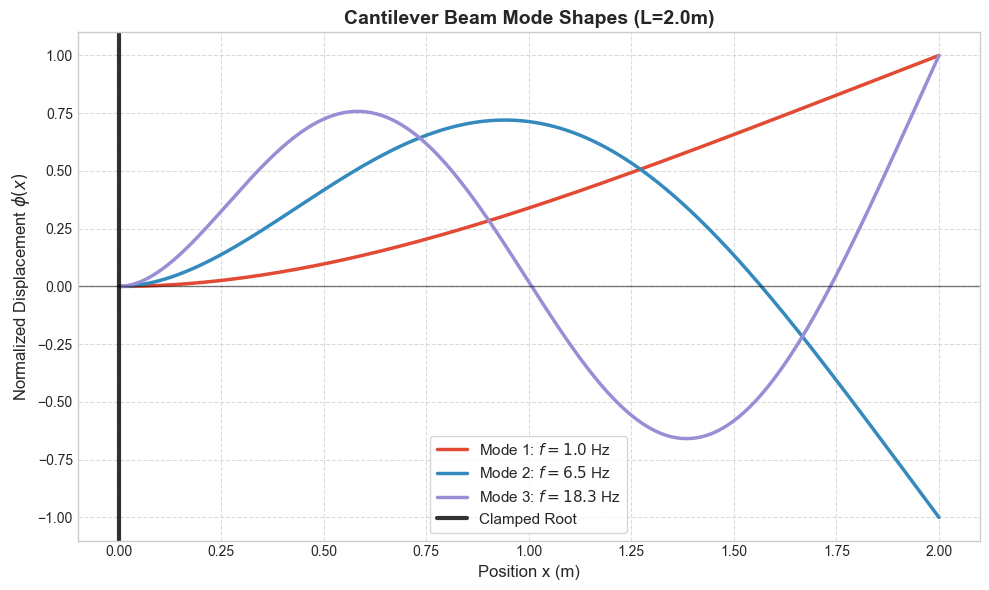

In [19]:
def plot_mode_shapes(df, L_val):
    x = np.linspace(0, L_val, 500)
    xi = x / L_val  # 无量纲坐标 0~1
    
    plt.figure(figsize=(10, 6), dpi=100)
    
    colors = ['#E24A33', '#348ABD', '#988ED5'] # 专业的配色
    
    for idx, row in df.iterrows():
        betaL = row['beta*L']
        sigma = row['Sigma_coeff']
        bx = betaL * xi # beta * x = (beta*L) * (x/L)
        
        # 悬臂梁标准振型函数
        # Phi(x) = (cosh(bx) - cos(bx)) - sigma * (sinh(bx) - sin(bx))
        Y = (np.cosh(bx) - np.cos(bx)) - sigma * (np.sinh(bx) - np.sin(bx))
        
        # 归一化：强制让末端 (Tip) 位移为 1
        #Y_normalized = Y / Y[-1]
        Y_normalized = Y / np.max(np.abs(Y))

        
        label_text = f"Mode {int(row['Mode'])}: $f={row['Freq (Hz)']:.1f}$ Hz"
        plt.plot(x, Y_normalized, label=label_text, linewidth=2.5, color=colors[idx % len(colors)])

    # 装饰图表
    plt.title(f'Cantilever Beam Mode Shapes (L={L_val}m)', fontsize=14, fontweight='bold')
    plt.xlabel('Position x (m)', fontsize=12)
    plt.ylabel('Normalized Displacement $\phi(x)$', fontsize=12)
    
    # 绘制参考线
    plt.axhline(0, color='black', linewidth=1, linestyle='-', alpha=0.5)
    plt.axvline(0, color='black', linewidth=3, linestyle='-', alpha=0.8, label='Clamped Root')
    
    plt.legend(frameon=True, fontsize=11)
    plt.grid(True, which='both', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# 运行绘图

plot_mode_shapes(df_results, PARAMS['L'])